#Dataset Link:
http://kaggle.com/datasets/salader/dogsvscats

In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

In [5]:
#downloading our dataset
!kaggle datasets download salader/dogsvscats

Dataset URL: https://www.kaggle.com/datasets/salader/dogsvscats
License(s): unknown
100% 1.06G/1.06G [00:12<00:00, 78.2MB/s]
100% 1.06G/1.06G [00:12<00:00, 95.0MB/s]


In [6]:
#unzipping the files
import zipfile
zip_ref = zipfile.ZipFile('/content/dogsvscats.zip','r')
zip_ref.extractall('/content')
zip_ref.close()


In [15]:
#importing libraries
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, BatchNormalization, Dropout
import matplotlib.pyplot as plt

In [8]:
#generators (to divide data into batches)
#for training dataset
train_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/train',
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,
    image_size = (256,256)
)
#for testing dataset
validation_ds = keras.utils.image_dataset_from_directory(
    directory = '/content/test',
    labels = 'inferred',
    label_mode = 'int',
    batch_size = 32,
    image_size = (256,256)
)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.


In [9]:
#Normalize
def process(image, label):
  image = tf.cast(image/255., tf.float32)
  return image,label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

#Create CNN Model

In [68]:
#CNN model
model = Sequential()
#adding layer
model.add(Conv2D(32,kernel_size=(3,3),padding='valid', activation= 'relu',input_shape=(256,256,3)))
model.add(BatchNormalization())
#pooling
model.add(MaxPooling2D(pool_size=(2,2),strides = 2,padding='valid'))

#adding layer
model.add(Conv2D(64,kernel_size=(3,3),padding='valid', activation= 'relu'))
model.add(BatchNormalization())
#pooling
model.add(MaxPooling2D(pool_size=(2,2),strides = 2,padding='valid'))

#adding layer
model.add(Conv2D(128,kernel_size=(3,3),padding='valid', activation= 'relu'))
model.add(BatchNormalization())
#pooling
model.add(MaxPooling2D(pool_size=(2,2),strides = 2,padding='valid'))

#adding layer
model.add(Conv2D(256,kernel_size=(3,3),padding='valid', activation= 'relu'))
model.add(BatchNormalization())
#pooling
model.add(MaxPooling2D(pool_size=(2,2),strides = 2,padding='valid'))

#flattening
model.add(Flatten())
#fully connected dense layers
model.add(Dense(256,activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(128,activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1, activation='sigmoid'))

#summary of model
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_20 (Conv2D)              │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 254, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 125, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 60, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 256)            │    12,845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,276,865 (50.65 MB)

 Trainable params: 13,275,905 (50.64 MB)

 Non-trainable params: 960 (3.75 KB)

In [69]:
#compiling the model
model.compile(
    optimizer='adam',
    loss= 'binary_crossentropy',
    metrics= ['accuracy']
)

In [70]:
history = model.fit(train_ds, epochs=9, validation_data=validation_ds)

Epoch 1/9
625/625 ━━━━━━━━━━━━━━━━━━━━ 69s 97ms/step - accuracy: 0.5373 - loss: 1.7571 - val_accuracy: 0.5744 - val_loss: 0.6598
Epoch 2/9
625/625 ━━━━━━━━━━━━━━━━━━━━ 60s 96ms/step - accuracy: 0.6472 - loss: 0.6323 - val_accuracy: 0.6942 - val_loss: 0.5834
Epoch 3/9
625/625 ━━━━━━━━━━━━━━━━━━━━ 60s 96ms/step - accuracy: 0.7288 - loss: 0.5429 - val_accuracy: 0.6828 - val_loss: 0.6288
Epoch 4/9
625/625 ━━━━━━━━━━━━━━━━━━━━ 60s 96ms/step - accuracy: 0.7942 - loss: 0.4501 - val_accuracy: 0.7232 - val_loss: 0.6144
Epoch 5/9
625/625 ━━━━━━━━━━━━━━━━━━━━ 62s 98ms/step - accuracy: 0.8455 - loss: 0.3596 - val_accuracy: 0.8156 - val_loss: 0.4052
Epoch 6/9
625/625 ━━━━━━━━━━━━━━━━━━━━ 63s 102ms/step - accuracy: 0.8894 - loss: 0.2723 - val_accuracy: 0.7932 - val_loss: 0.5683
Epoch 7/9
625/625 ━━━━━━━━━━━━━━━━━━━━ 64s 102ms/step - accuracy: 0.9273 - loss: 0.1811 - val_accuracy: 0.7392 - val_loss: 0.8226
Epoch 8/9
625/625 ━━━━━━━━━━━━━━━━━━━━ 61s 98ms/step - accuracy: 0.9523 - loss: 0.1275 - val_ac

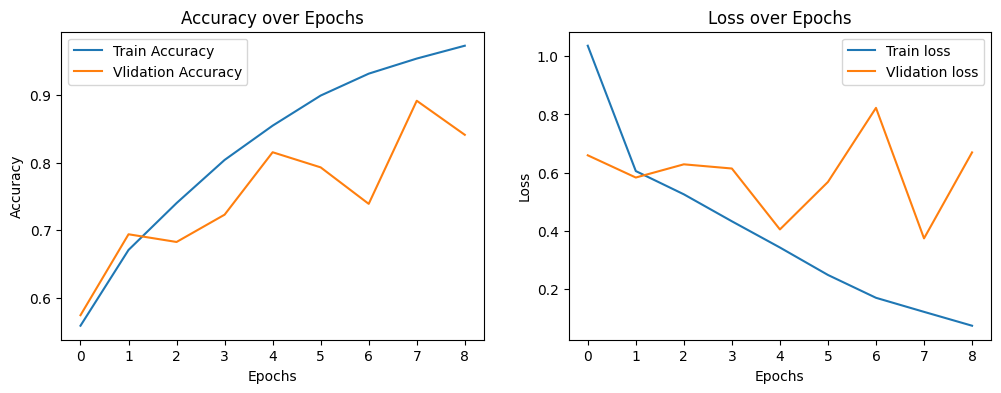

In [71]:
#plot training vs validation acuracy and loss
plt.figure(figsize=(12,4))

#Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label = 'Train Accuracy')
plt.plot(history.history['val_accuracy'], label = 'Vlidation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

#loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label = 'Train loss')
plt.plot(history.history['val_loss'], label = 'Vlidation loss')
plt.title('Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [72]:
import cv2

In [79]:
test_image1 = cv2.imread('/content/catimage.jpg')

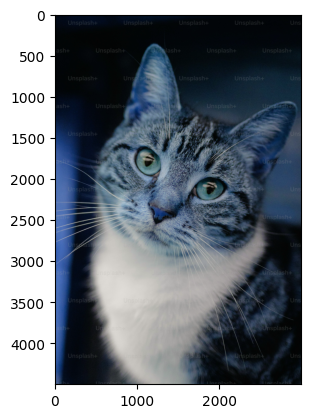

In [80]:
plt.imshow(test_image1)

In [81]:
test_image1.shape

(4499, 3000, 3)

In [82]:
test_image = cv2.resize(test_image1,(256,256))

In [83]:
test_input = test_image.reshape((1,256,256,3))

In [84]:
model.predict(test_input)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


array([[0.]], dtype=float32)

Here, the output of `model.predict()` is an array containing a single value.
- A value close to 0 indicates that the model predicts the image is a **cat**.
- A value close to 1 indicates that the model predicts the image is a **dog**.